In [1]:
import logging
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as patches

import sys
E9path = Path("C:/", "Users", "ken92", "Documents", "Studies", "E5", "simulation", "E9_simulations")
sys.path.insert(1, str(E9path))
import E9_fn.thermodynamics as thmdy
from E9_fn import util
from E9_fn.tight_binding import E9tb
from projects.flat_band_cooling import helper_fns as hpfn

logpath = '' # '' if not logging to a file
loglevel = logging.INFO
logroot = logging.getLogger()
list(map(logroot.removeHandler, logroot.handlers))
list(map(logroot.removeFilter, logroot.filters))
logging.basicConfig(filename = logpath, level = loglevel)

c:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\.venv\Lib\site-packages\gftool\precision.py:16: UserWarning: No quad precision datatypes available!
Some functions might be less accurate.
  warnings.warn("No quad precision datatypes available!\n"


In [2]:
lattice_str = "kagome"
lattice_len = 20
lattice_dim = (lattice_len, lattice_len)
overwrite_param = {}
# overwrite_param = {"sublat_offsets": [0., 0., 0., 15.]}
tb_params = E9tb.get_model_params(lattice_str, overwrite_param = overwrite_param)
my_tb_model = E9tb.tbmodel_2D(lat_dim = lattice_dim, **tb_params)
H_bare = my_tb_model.H

# Add offset to the bare model
sys_len = 12
sys_range = ((lattice_len - sys_len) // 2, (lattice_len + sys_len) // 2)
n_sys = sys_len**2
V_rsv_offset = -2.
# Find what unit cells are in the reservoir by excluding the unit cells in the system
sys_natural_uc_ind = set([(ii, jj) for jj in range(my_tb_model.lat_dim[1]) if sys_range[0] <= jj and jj < sys_range[1]
                                    for ii in range(my_tb_model.lat_dim[0]) if sys_range[0] <= ii and ii < sys_range[1]])
rsv_natural_uc_ind = set([(ii, jj) for jj in range(my_tb_model.lat_dim[1])
                                    for ii in range(my_tb_model.lat_dim[0])])
rsv_natural_uc_ind -= sys_natural_uc_ind
rsv_natural_uc_ind = np.array(list(rsv_natural_uc_ind))
logging.debug(rsv_natural_uc_ind)
rsv_ind = np.hstack(
    [my_tb_model.get_reduced_index(rsv_natural_uc_ind[:,0], rsv_natural_uc_ind[:,1], k)
        for k in range(my_tb_model.n_basis)])

H_offset = np.zeros_like(H_bare)
H_offset[rsv_ind, rsv_ind] = V_rsv_offset
H_total = H_bare + H_offset

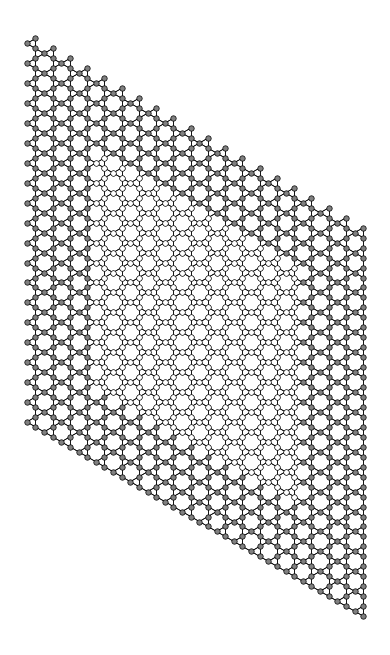

In [5]:
# fig_lat, axes_lat = plt.subplots(1, 3, figsize = (7, 4), width_ratios = [5, 1, 5])
fig, ax = plt.subplots(1, 1, figsize = (4, 9))

my_tb_model.plot_H(ax = ax, H = H_total,
                sublat_colors = ["gray", "gray", "gray"],
                sublat_alpha_min = 1,
                sublat_kwargs = {"edgecolors": "black",
                                    "linewidths": 0.5},
                plot_t = False)
my_tb_model.plot_H(ax = ax, H = H_total,
                sublat_colors = ["white", "white", "white"],
                sublat_alpha_min = 0.,
                sublat_kwargs = {   "edgecolors": "black",
                                    "linewidths": 0.3,
                                    "zorder": 101},
                t_kwargs = {"lw": 0.5})


# ax.set_xlim(-7.1, -0.2)
# ax.set_ylim(3.9, 10.8)
ax.set_xticks([])
ax.set_yticks([])
ax.spines[:].set_visible(False)

fig.tight_layout()

thesis_fig_path_app = Path(r"C:\Users\ken92\Documents\Studies\E5\Theses\figures\flatband")
file_full_path = Path(thesis_fig_path_app, "finite_tb_lat_difflim.pdf")
fig.savefig(file_full_path, facecolor = "none", dpi = 300, bbox_inches='tight')